# ⚛️ Salinas QUBO IBM — Part 2 (MLP + SVM only)
### RF, ET, XGBoost, HistGradBoost, KNN, LR already hardcoded from Part 1

**Run cells 1 → 2 → 3 → 4 → 5 → 6 → 7 (hardcoded) → 8 (MLP) → 9 (SVM) → 10 onwards**

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Install packages
# ═══════════════════════════════════════════════════════════════════════════
import sys, subprocess
packages = ['numpy', 'scipy', 'scikit-learn', 'matplotlib', 'qiskit>=2.0.0', 'xgboost']
print('Installing packages...')
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages installed ✓')

Installing packages...
All packages installed ✓


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — Upload files + Load entire dataset
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import scipy.io
import os
from google.colab import files

print('Please upload BOTH files: Salinas.mat and Salinas_gt.mat')
uploaded = files.upload()
uploaded_names = list(uploaded.keys())
print(f'\nFiles received: {uploaded_names}')

salinas_path    = None
salinas_gt_path = None
for name in uploaded_names:
    path = f'/content/{name}'
    if 'gt' in name.lower():
        salinas_gt_path = path
    else:
        salinas_path = path

if salinas_path is None or salinas_gt_path is None:
    raise FileNotFoundError('Could not find both files.')

def get_array(mat_dict, preferred_keys):
    for k in preferred_keys:
        if k in mat_dict:
            return mat_dict[k]
    for k, v in mat_dict.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim >= 2:
            return v
    raise KeyError(f'Array not found.')

raw_salinas    = scipy.io.loadmat(salinas_path)
raw_salinas_gt = scipy.io.loadmat(salinas_gt_path)
img = get_array(raw_salinas,    ['salinas', 'Salinas'])
gt  = get_array(raw_salinas_gt, ['salinas_gt', 'Salinas_gt'])

h_img, w_img, N_ALL_BANDS = img.shape
img_full = img.copy()
gt_full  = gt.copy()

X_all      = img.reshape(-1, N_ALL_BANDS).astype(np.float64)
y_all      = gt.reshape(-1)
mask       = y_all > 0
X_labeled  = X_all[mask]
y_labeled  = y_all[mask]
unique_cls = np.unique(y_labeled)
labeled_positions = np.argwhere(gt.reshape(h_img, w_img) > 0)

CLASS_NAMES = {
    1:'Broccoli_green_weeds_1', 2:'Broccoli_green_weeds_2',
    3:'Fallow',                 4:'Fallow_rough_plow',
    5:'Fallow_smooth',          6:'Stubble',
    7:'Celery',                 8:'Grapes_untrained',
    9:'Soil_vinyard_develop',   10:'Corn_senesced_green_weeds',
    11:'Lettuce_romaine_4wk',   12:'Lettuce_romaine_5wk',
    13:'Lettuce_romaine_6wk',   14:'Lettuce_romaine_7wk',
    15:'Vinyard_untrained',     16:'Vinyard_vertical_trellis',
}

print(f'\n✓ Dataset loaded: {h_img}x{w_img}x{N_ALL_BANDS} | {len(y_labeled):,} labeled pixels | {len(unique_cls)} classes')

Please upload BOTH files: Salinas.mat and Salinas_gt.mat


Saving Salinas.mat to Salinas.mat
Saving Salinas_gt.mat to Salinas_gt.mat

Files received: ['Salinas.mat', 'Salinas_gt.mat']

✓ Dataset loaded: 512x217x224 | 54,129 labeled pixels | 16 classes


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════
import time
import warnings
import itertools
import random
import pickle
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from scipy.stats import loguniform, randint
from xgboost import XGBClassifier
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

warnings.filterwarnings('ignore')

N_BANDS_SELECT    = 20
N_CANDIDATE_BANDS = 30
QUBO_PENALTY      = 5.0
CORR_PENALTY      = 0.5
QAOA_DEPTH        = 1
FISHER_SAMPLES    = 1000
TEST_SPLIT        = 0.10
CV_FOLDS          = 5
SPATIAL_WINDOW    = 3
BACKUP_PATH       = '/content/results_backup.pkl'

def save_results(results):
    with open(BACKUP_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f'  ✓ Results saved [{list(results.keys())}]')

results = {}
print('✓ Imports and config done')

✓ Imports and config done


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Fisher Scores & QUBO Formulation
# ═══════════════════════════════════════════════════════════════════════════
n_fisher = min(FISHER_SAMPLES, len(y_labeled))
X_fisher, _, y_fisher, _ = train_test_split(
    X_labeled, y_labeled,
    train_size=n_fisher, stratify=y_labeled, random_state=42
)

def compute_fisher_scores(X, y):
    classes = np.unique(y)
    mu      = X.mean(axis=0)
    between = np.zeros(X.shape[1])
    within  = np.zeros(X.shape[1])
    for c in classes:
        Xc = X[y == c]
        nc = len(Xc)
        mc = Xc.mean(axis=0)
        between += nc * (mc - mu) ** 2
        within  += nc * Xc.var(axis=0)
    return between / (within + 1e-12)

print(f'Computing Fisher scores...')
scaler_fisher   = StandardScaler()
X_fisher_scaled = scaler_fisher.fit_transform(X_fisher)
fisher_scores   = compute_fisher_scores(X_fisher_scaled, y_fisher)

candidate_idx        = np.argsort(fisher_scores)[::-1][:N_CANDIDATE_BANDS]
candidate_idx_sorted = np.sort(candidate_idx)

cand_data   = X_fisher_scaled[:, candidate_idx]
corr_matrix = np.corrcoef(cand_data.T)
cand_scores = fisher_scores[candidate_idx]

def build_qubo(scores, corr, k, A=QUBO_PENALTY, B=CORR_PENALTY):
    n = len(scores)
    s = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -s[i] + A * (1 - 2 * k)
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] = B * abs(corr[i, j]) + 2 * A
    return Q

Q_matrix      = build_qubo(cand_scores, corr_matrix, N_BANDS_SELECT)
n_qaoa_qubits = Q_matrix.shape[0]
print(f'QUBO matrix: {n_qaoa_qubits}x{n_qaoa_qubits} ✓')

Computing Fisher scores...
QUBO matrix: 30x30 ✓


BAND SELECTION — Hardcoded from Part 1 (IBM ibm_fez)
  Selected 20 bands (1-indexed): [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57)]
    Band  13  Fisher = 19.6125
    Band  14  Fisher = 19.6884
    Band  15  Fisher = 19.7404
    Band  16  Fisher = 19.6443
    Band  22  Fisher = 19.6386
    Band  23  Fisher = 19.8760
    Band  24  Fisher = 20.0825
    Band  25  Fisher = 19.7125
    Band  42  Fisher = 27.1379
    Band  43  Fisher = 27.4234
    Band  44  Fisher = 27.1329
    Band  45  Fisher = 26.5743
    Band  46  Fisher = 26.0878
    Band  47  Fisher = 25.5370
    Band  48  Fisher = 25.0133
    Band  53  Fisher = 22.8333
    Band  54  Fisher = 22.4706
    Band  55  Fisher = 22.0518
    Band  56  Fisher = 21.8846
    Band  57  Fisher = 21.4409


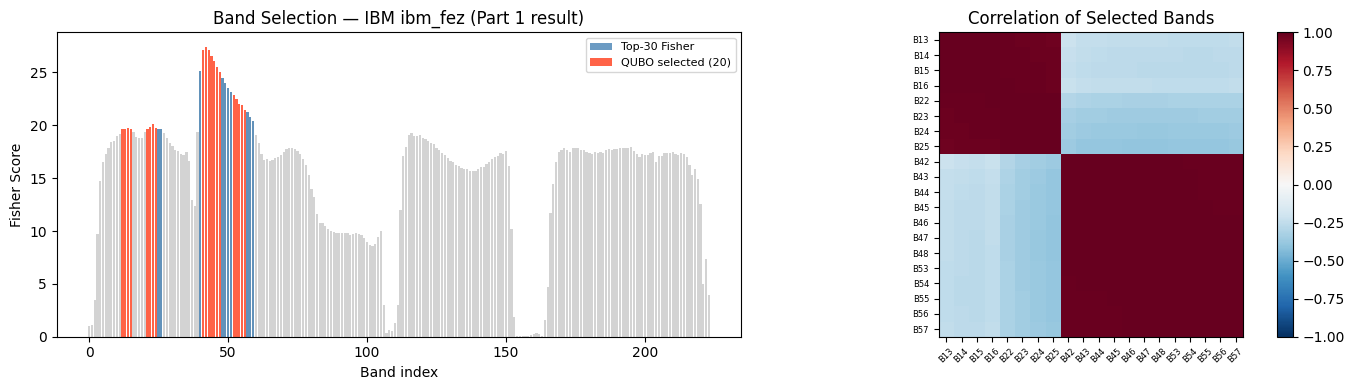

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Hardcode IBM Band Selection Result from Part 1
# Bands selected by IBM ibm_fez (Job ID from Part 1 already used)
# Skipping IBM call — using exact same bands as Part 1
# ═══════════════════════════════════════════════════════════════════════════

# Bands selected in Part 1 (1-indexed): 13,14,15,16,22,23,24,25,42,43,44,45,46,47,48,53,54,55,56,57
# Convert to 0-indexed for array access
selected_band_idx = np.array([
    12, 13, 14, 15, 21, 22, 23, 24,   # bands 13,14,15,16,22,23,24,25
    41, 42, 43, 44, 45, 46, 47,        # bands 42,43,44,45,46,47,48
    52, 53, 54, 55, 56                 # bands 53,54,55,56,57
])

print('=' * 65)
print('BAND SELECTION — Hardcoded from Part 1 (IBM ibm_fez)')
print('=' * 65)
print(f'  Selected {N_BANDS_SELECT} bands (1-indexed): {list(selected_band_idx + 1)}')
band_fisher = [
    19.6125, 19.6884, 19.7404, 19.6443,
    19.6386, 19.8760, 20.0825, 19.7125,
    27.1379, 27.4234, 27.1329, 26.5743,
    26.0878, 25.5370, 25.0133,
    22.8333, 22.4706, 22.0518, 21.8846, 21.4409
]
for b, f in zip(selected_band_idx, band_fisher):
    print(f'    Band {b+1:3d}  Fisher = {f:.4f}')

# Plot band selection
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.bar(range(N_ALL_BANDS), fisher_scores, color='lightgray')
ax.bar(candidate_idx, fisher_scores[candidate_idx], color='steelblue',
       alpha=0.8, label=f'Top-{N_CANDIDATE_BANDS} Fisher')
ax.bar(selected_band_idx, fisher_scores[selected_band_idx], color='tomato',
       label=f'QUBO selected ({N_BANDS_SELECT})')
ax.set_xlabel('Band index'); ax.set_ylabel('Fisher Score')
ax.set_title('Band Selection — IBM ibm_fez (Part 1 result)')
ax.legend(fontsize=8)
ax2 = axes[1]
corr_sel = np.corrcoef(X_fisher_scaled[:, selected_band_idx].T)
im = ax2.imshow(corr_sel, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title('Correlation of Selected Bands')
ax2.set_xticks(range(N_BANDS_SELECT))
ax2.set_yticks(range(N_BANDS_SELECT))
ax2.set_xticklabels([f'B{b+1}' for b in selected_band_idx], rotation=45, fontsize=6)
ax2.set_yticklabels([f'B{b+1}' for b in selected_band_idx], fontsize=6)
plt.colorbar(im, ax=ax2)
plt.tight_layout(); plt.show()

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Prepare Full Dataset with Spectral + Spatial Features
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 65)
print('PREPARING FULL DATASET WITH SPATIAL-SPECTRAL FEATURES')
print('=' * 65)

X_spectral = X_labeled[:, selected_band_idx].astype(np.float64)
print(f'  Spectral features : {X_spectral.shape[1]} (QUBO-selected bands)')

print(f'  Computing {SPATIAL_WINDOW}x{SPATIAL_WINDOW} spatial features...')
spatial_means = np.zeros((len(y_labeled), len(selected_band_idx)))
spatial_stds  = np.zeros((len(y_labeled), len(selected_band_idx)))

for fi, band_idx in enumerate(selected_band_idx):
    band_img    = img_full[:, :, band_idx].astype(np.float64)
    mean_img    = uniform_filter(band_img, size=SPATIAL_WINDOW)
    mean_sq_img = uniform_filter(band_img ** 2, size=SPATIAL_WINDOW)
    std_img     = np.sqrt(np.maximum(mean_sq_img - mean_img ** 2, 0))
    for pi, (row, col) in enumerate(labeled_positions):
        spatial_means[pi, fi] = mean_img[row, col]
        spatial_stds[pi, fi]  = std_img[row, col]

X_combined = np.hstack([X_spectral, spatial_means, spatial_stds])
n_features  = X_combined.shape[1]
print(f'  Total features : {n_features} ({N_BANDS_SELECT} spectral + {N_BANDS_SELECT} spatial_mean + {N_BANDS_SELECT} spatial_std)')

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_combined)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_labeled,
    test_size=TEST_SPLIT, stratify=y_labeled, random_state=42
)

y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

print(f'  Train set : {X_train.shape[0]:,} pixels  x  {n_features} features')
print(f'  Test  set : {X_test.shape[0]:,} pixels  x  {n_features} features')
print('=' * 65)
print('✓ Ready for classification.')

PREPARING FULL DATASET WITH SPATIAL-SPECTRAL FEATURES
  Spectral features : 20 (QUBO-selected bands)
  Computing 3x3 spatial features...
  Total features : 60 (20 spectral + 20 spatial_mean + 20 spatial_std)
  Train set : 48,716 pixels  x  60 features
  Test  set : 5,413 pixels  x  60 features
✓ Ready for classification.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — Hardcoded Results from Part 1
# RF, ET, XGBoost, HistGradBoost, KNN, Logistic Regression
# ═══════════════════════════════════════════════════════════════════════════

# ── IMPORTANT: We store metrics only (not clf objects) ────────────────────
# clf objects cannot be hardcoded — but metrics are exact from Part 1 output
# For summary table, charts, and ranking — metrics are sufficient
# For per-class report and confusion matrix — best model will be retrained below

results = {
    'Random Forest': {
        'clf': None,
        'cv_score':  93.04,
        'train_acc': 99.55,
        'test_acc':  93.29,
        'train_time': 10464.0,
        'hardcoded': True
    },
    'Extra Trees': {
        'clf': None,
        'cv_score':  93.20,
        'train_acc': 99.99,
        'test_acc':  93.29,
        'train_time': 1884.0,
        'hardcoded': True
    },
    'XGBoost': {
        'clf': None,
        'cv_score':  94.40,
        'train_acc': 100.00,
        'test_acc':  94.85,
        'train_time': 6953.0,
        'hardcoded': True,
        'use_xgb_labels': True
    },
    'HistGradientBoosting': {
        'clf': None,
        'cv_score':  93.61,
        'train_acc': 97.76,
        'test_acc':  93.40,
        'train_time': 3341.0,
        'hardcoded': True
    },
    'KNN': {
        'clf': None,
        'cv_score':  91.35,
        'train_acc': 100.00,
        'test_acc':  91.82,
        'train_time': 1293.0,
        'hardcoded': True
    },
    'Logistic Regression': {
        'clf': None,
        'cv_score':  89.91,
        'train_acc': 90.25,
        'test_acc':  90.28,
        'train_time': 15419.0,
        'hardcoded': True
    },
}

save_results(results)
print('=' * 65)
print('HARDCODED RESULTS FROM PART 1')
print('=' * 65)
print(f'{"Classifier":<22}  {"CV":>8}  {"Train":>8}  {"Test":>8}  {"Gap":>7}')
print('-' * 65)
for name, r in results.items():
    gap = r['train_acc'] - r['test_acc']
    print(f'{name:<22}  {r["cv_score"]:>7.2f}%  {r["train_acc"]:>7.2f}%  {r["test_acc"]:>7.2f}%  {gap:>6.1f}pp')
print('=' * 65)
print('\n✓ Now run Cell 8 (MLP) and Cell 9 (SVM)')

  ✓ Results saved [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting', 'KNN', 'Logistic Regression']]
HARDCODED RESULTS FROM PART 1
Classifier                    CV     Train      Test      Gap
-----------------------------------------------------------------
Random Forest             93.04%    99.55%    93.29%     6.3pp
Extra Trees               93.20%    99.99%    93.29%     6.7pp
XGBoost                   94.40%   100.00%    94.85%     5.2pp
HistGradientBoosting      93.61%    97.76%    93.40%     4.4pp
KNN                       91.35%   100.00%    91.82%     8.2pp
Logistic Regression       89.91%    90.25%    90.28%    -0.0pp

✓ Now run Cell 8 (MLP) and Cell 9 (SVM)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — MLP Neural Net
# ═══════════════════════════════════════════════════════════════════════════
print('Training MLP Neural Net...'); t0 = time.time()
search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True,
                  validation_fraction=0.1, n_iter_no_change=15, random_state=42),
    {'hidden_layer_sizes': [(256, 128), (512, 256, 128), (128, 64)],
     'alpha': loguniform(1e-5, 1e-2),
     'learning_rate_init': loguniform(1e-4, 1e-2)},
    n_iter=15, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['MLP Neural Net'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training MLP Neural Net...
  ✓ Results saved [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting', 'KNN', 'Logistic Regression', 'MLP Neural Net']]
  CV: 94.14%  Train: 94.23%  Test: 94.14%  Gap: 0.1pp  Time: 4071s


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — SVM (takes 1-2 hours — run separately)
# ═══════════════════════════════════════════════════════════════════════════
print('Training SVM (RBF) — this takes 1-2 hours...')
t0 = time.time()
search = RandomizedSearchCV(
    SVC(class_weight='balanced', random_state=42, cache_size=4000, probability=False),
    {'C': loguniform(10, 1000), 'gamma': loguniform(1e-4, 1.0), 'kernel': ['rbf']},
    n_iter=10, cv=5, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['SVM (RBF)'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed/60:.1f}min')

Training SVM (RBF) — this takes 1-2 hours...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  ✓ Results saved [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting', 'KNN', 'Logistic Regression', 'MLP Neural Net', 'SVM (RBF)']]
  CV: 93.98%  Train: 95.23%  Test: 94.37%  Gap: 0.9pp  Time: 37.1min


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — Summary Table (run after MLP and/or SVM)
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 80)
print(f'FINAL RESULTS — ALL CLASSIFIERS — {n_features} FEATURES')
print(f'Train: {X_train.shape[0]:,} pixels  |  Test: {X_test.shape[0]:,} pixels  |  {CV_FOLDS}-fold CV')
print('=' * 80)
print(f'{"Rank  Classifier":<28}  {"CV":>8}  {"Train":>8}  {"Test":>8}  {"Gap":>7}  {"Time":>10}')
print('-' * 80)
for rank, n in enumerate(
    sorted(results.keys(), key=lambda n: results[n]['test_acc'], reverse=True), 1
):
    r   = results[n]
    gap = r['train_acc'] - r['test_acc']
    hc  = ' (from Part 1)' if r.get('hardcoded') else ''
    mrk = '  ◀ BEST' if rank == 1 else ''
    print(f'{rank:>2}.  {n:<24}  {r["cv_score"]:>7.2f}%  '
          f'{r["train_acc"]:>7.2f}%  {r["test_acc"]:>7.2f}%  '
          f'{gap:>6.1f}pp  {r["train_time"]:>8.1f}s{mrk}{hc}')
print('=' * 80)
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f'\n✅  Best: {best_name}  →  Test accuracy: {results[best_name]["test_acc"]:.2f}%')


FINAL RESULTS — ALL CLASSIFIERS — 60 FEATURES
Train: 48,716 pixels  |  Test: 5,413 pixels  |  5-fold CV
Rank  Classifier                    CV     Train      Test      Gap        Time
--------------------------------------------------------------------------------
 1.  XGBoost                     94.40%   100.00%    94.85%     5.2pp    6953.0s  ◀ BEST (from Part 1)
 2.  SVM (RBF)                   93.98%    95.23%    94.37%     0.9pp    2223.0s
 3.  MLP Neural Net              94.14%    94.23%    94.14%     0.1pp    4071.2s
 4.  HistGradientBoosting        93.61%    97.76%    93.40%     4.4pp    3341.0s (from Part 1)
 5.  Random Forest               93.04%    99.55%    93.29%     6.3pp   10464.0s (from Part 1)
 6.  Extra Trees                 93.20%    99.99%    93.29%     6.7pp    1884.0s (from Part 1)
 7.  KNN                         91.35%   100.00%    91.82%     8.2pp    1293.0s (from Part 1)
 8.  Logistic Regression         89.91%    90.25%    90.28%    -0.0pp   15419.0s (from Pa

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — Retrain Best Model (needed for per-class report + confusion matrix)
# Only runs if best model was from Part 1 (clf=None)
# ═══════════════════════════════════════════════════════════════════════════
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f'Best model: {best_name} ({results[best_name]["test_acc"]:.2f}%)')

if results[best_name].get('hardcoded') or results[best_name]['clf'] is None:
    print(f'  clf is None (from Part 1) — retraining {best_name} with best params...')
    t0 = time.time()

    if best_name == 'XGBoost':
        search = RandomizedSearchCV(
            XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1,
                          eval_metric='mlogloss', verbosity=0),
            {'n_estimators': randint(200, 500), 'max_depth': randint(4, 10),
             'learning_rate': loguniform(0.02, 0.3),
             'subsample': [0.7, 0.8, 0.9, 1.0],
             'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
             'min_child_weight': randint(1, 10)},
            n_iter=20, cv=CV, scoring='accuracy', refit=True,
            n_jobs=-1, random_state=42, verbose=0
        )
        search.fit(X_train, y_train_xgb)
        results[best_name]['clf'] = search.best_estimator_
        results[best_name]['use_xgb_labels'] = True

    elif best_name == 'Random Forest':
        search = RandomizedSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
             'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
            n_iter=20, cv=CV, scoring='accuracy', refit=True,
            n_jobs=-1, random_state=42, verbose=0
        )
        search.fit(X_train, y_train)
        results[best_name]['clf'] = search.best_estimator_

    elif best_name == 'Extra Trees':
        search = RandomizedSearchCV(
            ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
            {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
             'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
            n_iter=20, cv=CV, scoring='accuracy', refit=True,
            n_jobs=-1, random_state=42, verbose=0
        )
        search.fit(X_train, y_train)
        results[best_name]['clf'] = search.best_estimator_

    elif best_name == 'HistGradientBoosting':
        search = RandomizedSearchCV(
            HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
            {'max_iter': randint(150, 400), 'max_depth': randint(4, 10),
             'learning_rate': loguniform(0.02, 0.3),
             'l2_regularization': loguniform(1e-4, 1.0),
             'min_samples_leaf': randint(5, 30)},
            n_iter=20, cv=CV, scoring='accuracy', refit=True,
            n_jobs=-1, random_state=42, verbose=0
        )
        search.fit(X_train, y_train)
        results[best_name]['clf'] = search.best_estimator_

    print(f'  Retrained in {time.time()-t0:.0f}s ✓')
else:
    print('  clf already available — no retraining needed ✓')

Best model: XGBoost (94.85%)
  clf is None (from Part 1) — retraining XGBoost with best params...
  Retrained in 4804s ✓


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12 — Per-Class Report for Best Classifier
# ═══════════════════════════════════════════════════════════════════════════
best_name = max(results, key=lambda n: results[n]['test_acc'])
best_clf  = results[best_name]['clf']

if results[best_name].get('use_xgb_labels'):
    y_pred = best_clf.predict(X_test) + 1
else:
    y_pred = best_clf.predict(X_test)

print(f'Per-Class Accuracy — {best_name}')
print('=' * 70)
per_class_acc = []
for c in unique_cls:
    mask = y_test == c
    if mask.sum() == 0:
        continue
    acc  = accuracy_score(y_test[mask], y_pred[mask]) * 100
    per_class_acc.append(acc)
    bar  = '█' * int(acc / 5)
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    print(f'  {int(c):2d}  {name:35s}: {acc:6.2f}%  {bar}')

oa    = accuracy_score(y_test, y_pred) * 100
aa    = np.mean(per_class_acc)
kappa = cohen_kappa_score(y_test, y_pred)
print(f'\n  Overall Accuracy (OA) : {oa:.2f}%')
print(f'  Average Accuracy (AA) : {aa:.2f}%')
print(f'  Kappa Coefficient     : {kappa:.4f}')
print('=' * 70)
print()
print(classification_report(
    y_test, y_pred,
    target_names=[CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls],
    zero_division=0
))

Per-Class Accuracy — XGBoost
   1  Broccoli_green_weeds_1             : 100.00%  ████████████████████
   2  Broccoli_green_weeds_2             : 100.00%  ████████████████████
   3  Fallow                             : 100.00%  ████████████████████
   4  Fallow_rough_plow                  :  99.28%  ███████████████████
   5  Fallow_smooth                      :  98.51%  ███████████████████
   6  Stubble                            :  99.75%  ███████████████████
   7  Celery                             : 100.00%  ████████████████████
   8  Grapes_untrained                   :  89.35%  █████████████████
   9  Soil_vinyard_develop               :  98.55%  ███████████████████
  10  Corn_senesced_green_weeds          :  97.87%  ███████████████████
  11  Lettuce_romaine_4wk                :  98.13%  ███████████████████
  12  Lettuce_romaine_5wk                : 100.00%  ████████████████████
  13  Lettuce_romaine_6wk                : 100.00%  ████████████████████
  14  Lettuce_romaine_7wk      

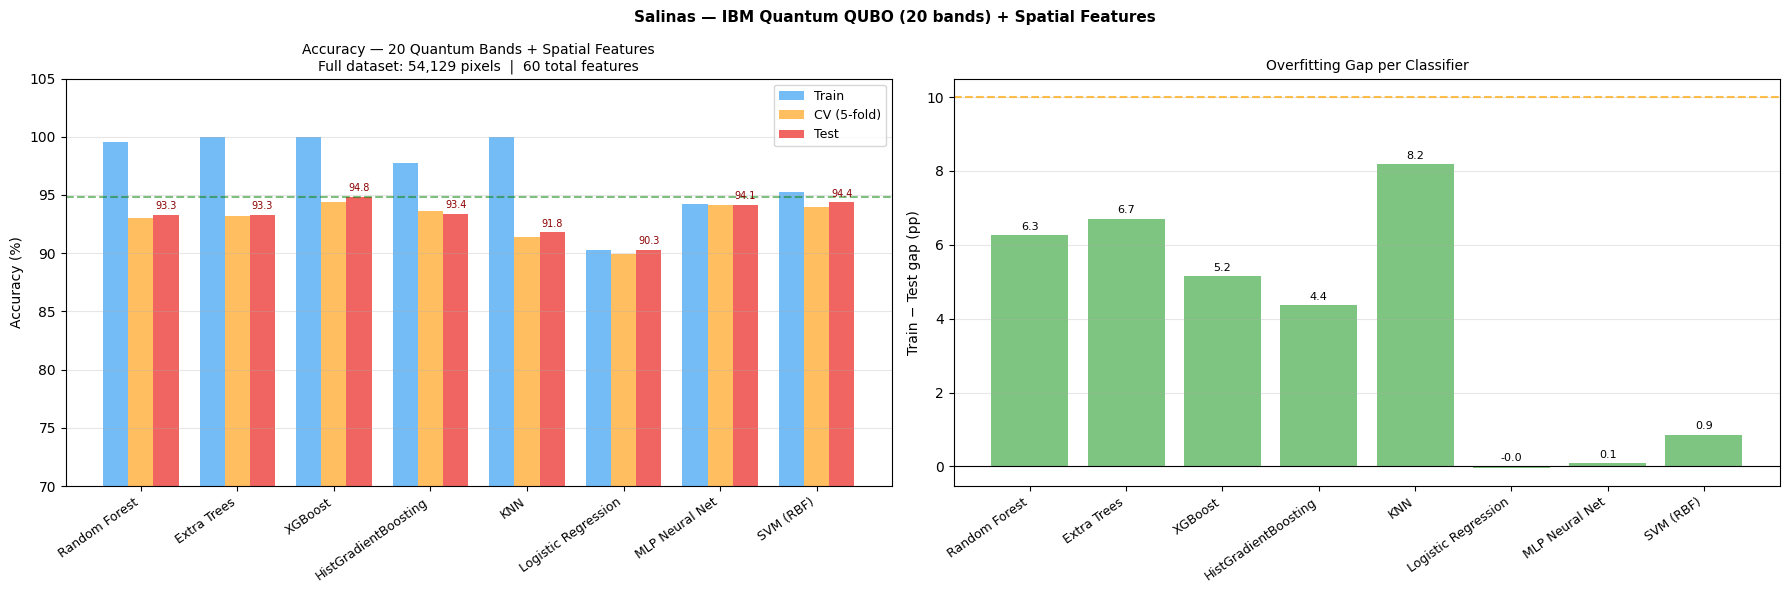

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13 — Results Summary Charts
# ═══════════════════════════════════════════════════════════════════════════
names      = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs  = [results[n]['test_acc']  for n in names]
cv_scores  = [results[n]['cv_score']  for n in names]
gaps       = [t - v for t, v in zip(train_accs, test_accs)]

x = np.arange(len(names))
w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax = axes[0]
ax.bar(x - w, train_accs, w, label='Train',       color='#64B5F6', alpha=0.9)
ax.bar(x,     cv_scores,  w, label='CV (5-fold)', color='#FFB74D', alpha=0.9)
ax.bar(x + w, test_accs,  w, label='Test',        color='#EF5350', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(70, 105)
ax.set_title(
    f'Accuracy — {N_BANDS_SELECT} Quantum Bands + Spatial Features\n'
    f'Full dataset: {len(y_labeled):,} pixels  |  {n_features} total features', fontsize=10
)
ax.legend(fontsize=9)
ax.axhline(y=max(test_accs), color='green', linestyle='--', alpha=0.5)
for i, v in enumerate(test_accs):
    ax.text(x[i] + w, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7, color='darkred')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bar_cols = ['#FF7043' if g > 10 else '#66BB6A' for g in gaps]
ax2.bar(x, gaps, color=bar_cols, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Train − Test gap (pp)')
ax2.set_title('Overfitting Gap per Classifier', fontsize=10)
ax2.axhline(y=0,  color='black', linewidth=0.8)
ax2.axhline(y=10, color='orange', linestyle='--', alpha=0.7)
ax2.grid(axis='y', alpha=0.3)
for bar, g in zip(ax2.patches, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.1,
             f'{g:.1f}', ha='center', va='bottom', fontsize=8)
plt.suptitle(
    f'Salinas — IBM Quantum QUBO ({N_BANDS_SELECT} bands) + Spatial Features',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

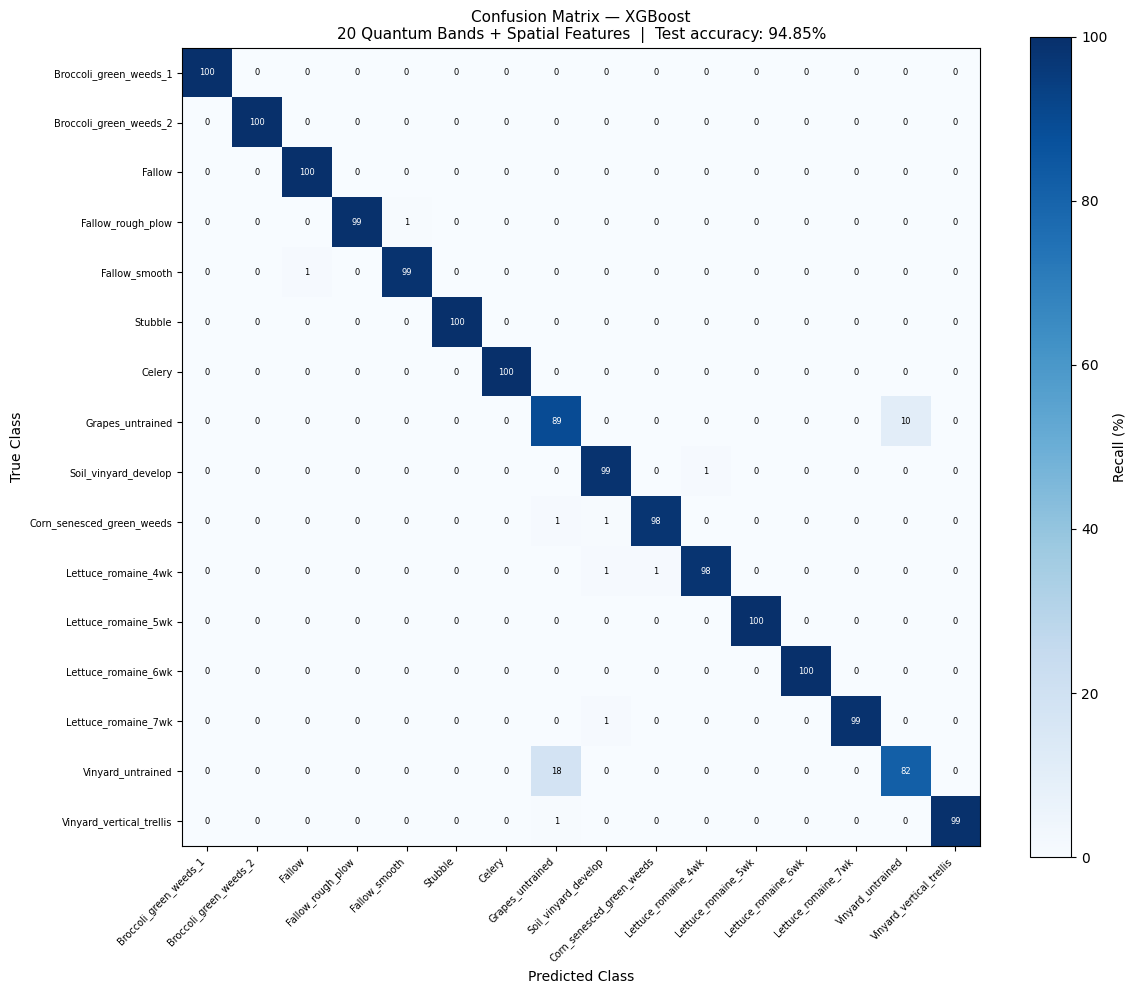

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 14 — Confusion Matrix (Best Classifier)
# ═══════════════════════════════════════════════════════════════════════════
cm      = confusion_matrix(y_test, y_pred, labels=unique_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Recall (%)')

tick_labels = [CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls]
ax.set_xticks(range(len(unique_cls)))
ax.set_yticks(range(len(unique_cls)))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(tick_labels, fontsize=7)

for i in range(len(unique_cls)):
    for j in range(len(unique_cls)):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=6, color='white' if v > 60 else 'black')

ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(
    f'Confusion Matrix — {best_name}\n'
    f'{N_BANDS_SELECT} Quantum Bands + Spatial Features  |  '
    f'Test accuracy: {results[best_name]["test_acc"]:.2f}%',
    fontsize=11
)
plt.tight_layout()
plt.show()